In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [ ]:
df = pd.read_csv("feature_engineered_superstore.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales_category,high_profit,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Medium,1,816.0,8.691176,1,14,0,1,0,3
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,360.0,8.100000,1,15,9,0,0,3
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Low,1,264.0,12.378788,1,14,5,3,0,2
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Low,0,135.0,10.711111,1,12,7,4,2,2
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,570.0,4.122807,0,9,9,0,0,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               51290 non-null  object 
 1   order_date             51290 non-null  object 
 2   ship_date              51290 non-null  object 
 3   ship_mode              51290 non-null  object 
 4   customer_name          51290 non-null  object 
 5   segment                51290 non-null  object 
 6   state                  51290 non-null  object 
 7   country                51290 non-null  object 
 8   market                 51290 non-null  object 
 9   region                 51290 non-null  object 
 10  product_id             51290 non-null  object 
 11  category               51290 non-null  object 
 12  sub_category           51290 non-null  object 
 13  product_name           51290 non-null  object 
 14  sales                  48660 non-null  float64
 15  qu

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
# Select Features
features = [
"quantity",
"discount",
"profit",
"shipping_cost",
"delivery_days",
"profit_margin",
"average_selling_price",
"category_encoded",
"sub_category_encoded",
"market_encoded",
"region_encoded",
"segment_encoded",
"ship_mode_encoded"
]
X = df[features]
y = df["sales"]

In [ ]:
mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression MSE: {mse:.2f}")
print(f"Linear Regression R2 Score: {r2:.2f}")

Linear Regression MAE: 51.89
Linear Regression MSE: 8030.45
Linear Regression R2 Score: 0.80


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Re-select features and split data after cleaning infinities
X = df[features]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(X_train.shape)
print(X_test.shape)

# Retrain Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

(38927, 13)
(9732, 13)


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Re-select features and split data after cleaning infinities
X = df[features]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(X_train.shape)
print(X_test.shape)

# Retrain Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

(38927, 13)
(9732, 13)


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Re-select features and split data after cleaning infinities
X = df[features]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(X_train.shape)
print(X_test.shape)

# Retrain Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

(38927, 13)
(9732, 13)


In [ ]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [ ]:
# Linear Regression Evaluation

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_mse = mean_squared_error(y_test, lr_predictions)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R2 :", lr_r2)

Linear Regression
MAE : 51.88925712176229
RMSE : 89.61278477476495
R2 : 0.8026187706778745


In [ ]:
# Decision Tree

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_predictions = dt.predict(X_test)

In [ ]:
# Decision Tree Evaluation

dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(y_test, dt_predictions)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree")

print("MAE :", dt_mae)

print("RMSE :", dt_rmse)

print("R2 :", dt_r2)

Decision Tree
MAE : 0.9823263460748047
RMSE : 6.136597578439055
R2 : 0.9990744045923708


In [ ]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Random Forest Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 :", rf_r2)

Random Forest
MAE : 6.2564183491893335
RMSE : 12.22394376624266
R2 : 0.9963272734948989


In [ ]:
# Compare Models

comparison = pd.DataFrame({

"Model":[

"Linear Regression",

"Decision Tree",

"Random Forest"

],

"MAE":[

lr_mae,

dt_mae,

rf_mae

],

"RMSE":[

lr_rmse,

dt_rmse,

rf_rmse

],

"R2 Score":[

lr_r2,

dt_r2,

rf_r2

]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,51.889257,89.612785,0.802619
1,Decision Tree,0.982326,6.136598,0.999074
2,Random Forest,6.256418,12.223944,0.996327


In [ ]:
# Best Model

best_model = comparison.sort_values(

by="R2 Score",

ascending=False

)

best_model

,Model,MAE,RMSE,R2 Score
1,Decision Tree,0.982326,6.136598,0.999074
2,Random Forest,6.256418,12.223944,0.996327
0,Linear Regression,51.889257,89.612785,0.802619


In [ ]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

# Feature Importance
importance = pd.Series(
rf.feature_importances_,
index=features
).sort_values(ascending=False)

importance

,0
shipping_cost,0.571139
average_selling_price,0.271902
quantity,0.144043
profit,0.010020
profit_margin,0.002193
delivery_days,0.000632
ship_mode_encoded,0.000019
region_encoded,0.000013
sub_category_encoded,0.000013
market_encoded,0.000010


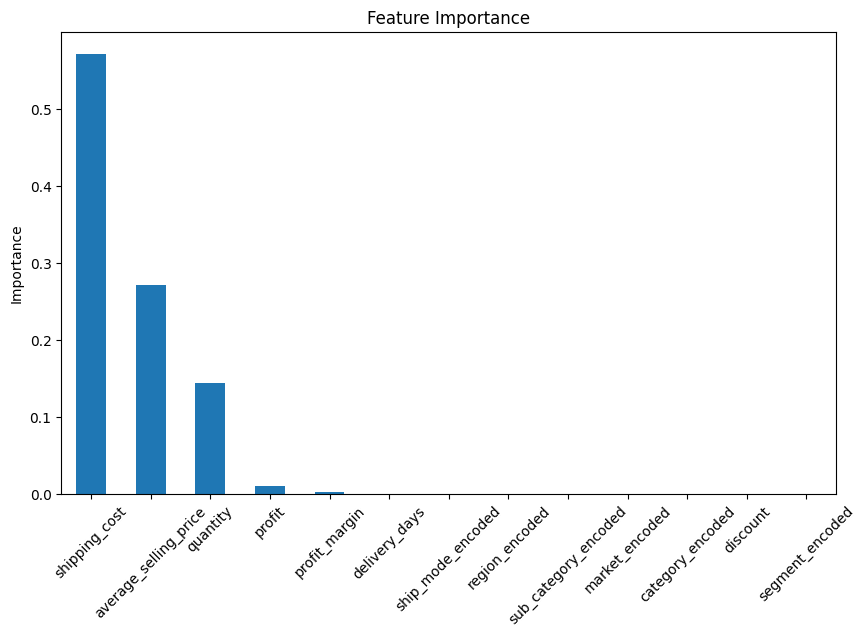

In [ ]:
# Plot Feature Importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

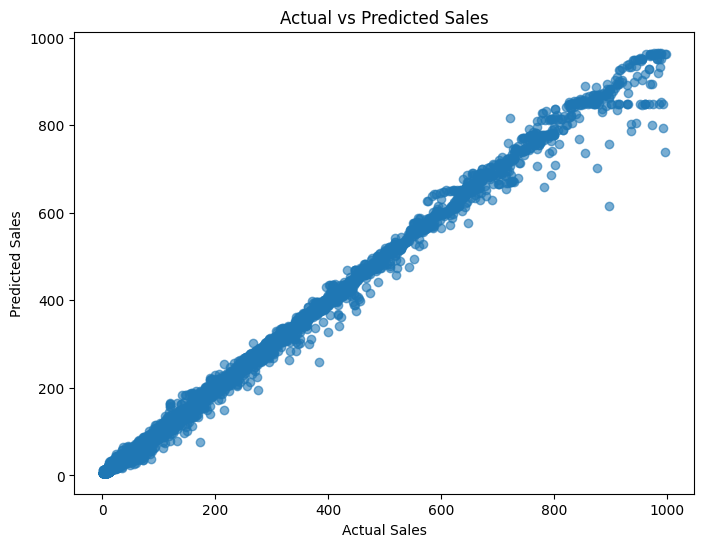

In [ ]:
# Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(

y_test,

rf_predictions,

alpha=0.6

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
# Save Best Model

joblib.dump(

rf,

"sales_prediction_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("sales_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
comparison.to_csv(

"model_comparison.csv",

index=False

)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,51.889257,89.612785,0.802619
1,Decision Tree,0.982326,6.136598,0.999074
2,Random Forest,6.256418,12.223944,0.996327


In [ ]:
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>